# Solana Investigation

This notebook rebuilds the Solana section around real 7-day, 1-second reserve data where that is honest. It first diagnoses the venue universe from official Orca, Raydium, and Meteora APIs, then reconstructs the selected reserve-based pools directly from Solana RPC block data.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT)),

from solana_second_level import dataset_summary_frame, load_or_build_solana_dataset

REFRESH_SOLANA_DATA = False
dataset = load_or_build_solana_dataset(project_root=PROJECT_ROOT, refresh=REFRESH_SOLANA_DATA)

display(dataset_summary_frame(dataset))
display(pd.DataFrame(dataset['selected_pools']))
display(pd.DataFrame(dataset['qc_report'].items(), columns=['check', 'value']))


[solana] reusing signatures for raydium_cpmm: 3989 rows
[solana] raydium_cpmm: collected 3989 signatures
[solana] reusing reserve events for raydium_cpmm: 856 rows
[solana] raydium_cpmm: parsed 856 reserve events
[solana] reusing signatures for meteora_damm_v2: 6342 rows
[solana] meteora_damm_v2: collected 6342 signatures
[solana] fetching blocks for meteora_damm_v2
[solana] meteora_damm_v2: processed 3/3115 slots
[solana] meteora_damm_v2: processed 60/3115 slots
[solana] meteora_damm_v2: processed 120/3115 slots
[solana] meteora_damm_v2: processed 180/3115 slots
[solana] meteora_damm_v2: processed 240/3115 slots
[solana] meteora_damm_v2: processed 300/3115 slots
[solana] meteora_damm_v2: processed 360/3115 slots
[solana] meteora_damm_v2: processed 420/3115 slots
[solana] meteora_damm_v2: processed 480/3115 slots
[solana] meteora_damm_v2: processed 540/3115 slots
[solana] meteora_damm_v2: processed 600/3115 slots
[solana] meteora_damm_v2: processed 660/3115 slots
[solana] meteora_damm_

,field,value
0,status,supported_with_limitations
1,window_start_utc,2026-04-12T06:31:51+00:00
2,window_end_utc,2026-04-19T06:31:51+00:00
3,selected_pool_count,2
4,venue_catalog_rows,81
5,pool_event_rows,3956
6,pool_state_rows,521389
7,arb_label_rows,259077
8,network_fee_lamports_floor,5000
9,network_fee_lamports_p95,106492


,dex,pool_address,pool_name,pool_type,tvl_usd,volume_24h_usd,fee_rate_floor,fee_model,reconstructable_reason
0,raydium_cpmm,47hq28mcL7q5GhBg7epyGF2dnuJd4MKFt8QhT7CzYUp4,Raydium Standard SOL/USDC,Cpmm,132.200000,817.337778,0.0030,exact_fixed_fee,Raydium CPMM exposes direct pool vaults and fi...
1,meteora_damm_v2,Ft8FD9gg1TdawhWijNzdkpYTiVL8ETfY6gAwS24bwYio,SOL-USDC,full_range,3270.369387,378.897345,0.0025,lower_bound_base_fee,Meteora DAMM v2 exposes direct pool vaults and...


,check,value
0,duplicate_events,0
1,non_positive_reserves,0
2,pool_state_nulls,0
3,arb_label_nulls,0
4,passed,True


In [2]:
venue_columns = [
    'dex', 'source', 'pool_address', 'pool_type', 'tvl_usd', 'volume_24h_usd',
    'fee_rate_floor', 'fee_model', 'reconstructable', 'reconstructable_reason'
]
venue_catalog = dataset['venue_catalog'].copy()
display(Markdown('## Official Venue Diagnosis'))
display(venue_catalog.loc[:, [column for column in venue_columns if column in venue_catalog.columns]])

display(Markdown('## Selected Pools'))
display(pd.DataFrame(dataset['selected_pools']))

display(Markdown('## Fee Bounds Used In The Lower-Bound Profit Screen'))
display(pd.DataFrame([dataset['fee_bounds']]))


## Official Venue Diagnosis

,dex,source,pool_address,pool_type,tvl_usd,volume_24h_usd,fee_rate_floor,fee_model,reconstructable,reconstructable_reason
0,raydium_cpmm,raydium_v3_api,47hq28mcL7q5GhBg7epyGF2dnuJd4MKFt8QhT7CzYUp4,Cpmm,132.200000,817.337778,0.003000,exact_fixed_fee,True,Raydium CPMM exposes direct pool vaults and fi...
1,meteora_damm_v2,meteora_damm_v2_api,Ft8FD9gg1TdawhWijNzdkpYTiVL8ETfY6gAwS24bwYio,full_range,3270.369387,378.897345,0.002500,lower_bound_base_fee,True,Meteora DAMM v2 exposes direct pool vaults and...
2,meteora_damm_v2,meteora_damm_v2_api,6B3Nx4BTx24SqV3Vk6ZdVZXNLMWb32GYWjour3Hirnmr,full_range,120.468561,5.535800,0.002500,lower_bound_base_fee,True,Meteora DAMM v2 exposes direct pool vaults and...
3,meteora_damm_v2,meteora_damm_v2_api,AoubhKSK3rbYhReB1Z2zPf7Eia4mN581mKi65YpBp1dF,full_range,39.995452,4.652821,0.009968,lower_bound_base_fee,True,Meteora DAMM v2 exposes direct pool vaults and...
4,meteora_damm_v2,meteora_damm_v2_api,BbRiZGpXnUeGenwu6L41YR3VtfWbGMbmXzTk95cYDsgb,full_range,2.512287,3.124306,0.002498,lower_bound_base_fee,True,Meteora DAMM v2 exposes direct pool vaults and...
...,...,...,...,...,...,...,...,...,...,...
76,orca_whirlpool,orca_public_api,CCycTBsvf1hPtZMwoy9jzhpt33baaKAZ7FLk5frEUisp,whirlpool,NaN,NaN,NaN,blocked,False,Orca SOL/USDC pools are Whirlpool/Splash-style...
77,orca_whirlpool,orca_public_api,21gTfxAnhUDjJGZJDkTXctGFKT8TeiXx6pN1CEg9K1uW,whirlpool,NaN,NaN,NaN,blocked,False,Orca SOL/USDC pools are Whirlpool/Splash-style...
78,orca_whirlpool,orca_public_api,7xuPLn8Bun4ZGHeD95xYLnPKReKtSe7zfVRzRJWJZVZW,whirlpool,NaN,NaN,NaN,blocked,False,Orca SOL/USDC pools are Whirlpool/Splash-style...
79,orca_whirlpool,orca_public_api,CrD1GoH1E2K1Qj94CQCG75PYkJRGrvcG9GucU3DpXjj3,splashpool,NaN,NaN,NaN,blocked,False,Orca SOL/USDC pools are Whirlpool/Splash-style...


## Selected Pools

,dex,pool_address,pool_name,pool_type,tvl_usd,volume_24h_usd,fee_rate_floor,fee_model,reconstructable_reason
0,raydium_cpmm,47hq28mcL7q5GhBg7epyGF2dnuJd4MKFt8QhT7CzYUp4,Raydium Standard SOL/USDC,Cpmm,132.200000,817.337778,0.0030,exact_fixed_fee,Raydium CPMM exposes direct pool vaults and fi...
1,meteora_damm_v2,Ft8FD9gg1TdawhWijNzdkpYTiVL8ETfY6gAwS24bwYio,SOL-USDC,full_range,3270.369387,378.897345,0.0025,lower_bound_base_fee,Meteora DAMM v2 exposes direct pool vaults and...


## Fee Bounds Used In The Lower-Bound Profit Screen

,network_fee_lamports_floor,network_fee_lamports_p95
0,5000,106492


In [3]:
arb_labels = dataset['arb_labels'].copy()
size_sensitivity = dataset['size_sensitivity'].copy()
opportunity_windows = dataset['opportunity_windows'].copy()

display(Markdown('## Size Sensitivity (Lower-Bound Fee Model)'))
display(size_sensitivity)

top_columns = [
    'timestamp', 'buy_dex', 'sell_dex', 'trade_size_base', 'gross_edge_quote',
    'edge_after_pool_fees_quote_floor', 'network_fee_quote_floor', 'network_fee_quote_p95',
    'net_edge_quote_floor', 'net_edge_quote_p95', 'net_edge_bps_floor', 'net_edge_bps_p95',
    'positive_after_pool_fees_floor', 'positive_after_network_floor', 'positive_after_network_p95'
]
display(Markdown('## Top Seconds'))
display(arb_labels.sort_values('net_edge_bps_floor', ascending=False).head(20).loc[:, [c for c in top_columns if c in arb_labels.columns]])

display(Markdown('## Opportunity Windows (Network Fee Floor)'))
display(opportunity_windows.head(20))


## Size Sensitivity (Lower-Bound Fee Model)

,trade_size_base,observed_seconds,gross_positive_seconds,pool_fee_floor_positive_seconds,network_floor_positive_seconds,network_p95_positive_seconds,max_net_edge_bps_floor,mean_net_edge_bps_floor
0,0.00010,259077,259077,85069,85069,1728,182046.919544,3793.544761
1,0.00025,259077,259077,85069,85069,3856,185152.391677,4157.318809
2,0.00050,259077,259077,85069,85069,3856,186173.965351,4275.379672
3,0.00100,259077,259077,85069,85069,40711,186659.283922,4328.415724
4,0.00250,259077,259077,85069,85069,85069,186868.986049,4341.057609
5,0.00500,259077,259077,85069,85069,85069,186803.103165,4313.312874
6,0.01000,259077,259077,85069,85069,85069,186515.685314,4239.546246


## Top Seconds

,timestamp,buy_dex,sell_dex,trade_size_base,gross_edge_quote,edge_after_pool_fees_quote_floor,network_fee_quote_floor,network_fee_quote_p95,net_edge_quote_floor,net_edge_quote_p95,net_edge_bps_floor,net_edge_bps_p95,positive_after_pool_fees_floor,positive_after_network_floor,positive_after_network_p95
25792,2026-04-15 09:41:00+00:00,raydium_cpmm,meteora_damm_v2,0.001,0.083028,0.082796,0.00023,0.004891,0.082567,0.077906,186659.283922,176121.885154,False,False,False
25821,2026-04-15 09:41:29+00:00,raydium_cpmm,meteora_damm_v2,0.001,0.083028,0.082796,0.00023,0.004891,0.082567,0.077906,186659.283922,176121.885154,False,False,False
25814,2026-04-15 09:41:22+00:00,raydium_cpmm,meteora_damm_v2,0.001,0.083028,0.082796,0.00023,0.004891,0.082567,0.077906,186659.283922,176121.885154,False,False,False
25815,2026-04-15 09:41:23+00:00,raydium_cpmm,meteora_damm_v2,0.001,0.083028,0.082796,0.00023,0.004891,0.082567,0.077906,186659.283922,176121.885154,False,False,False
25816,2026-04-15 09:41:24+00:00,raydium_cpmm,meteora_damm_v2,0.001,0.083028,0.082796,0.00023,0.004891,0.082567,0.077906,186659.283922,176121.885154,False,False,False
25817,2026-04-15 09:41:25+00:00,raydium_cpmm,meteora_damm_v2,0.001,0.083028,0.082796,0.00023,0.004891,0.082567,0.077906,186659.283922,176121.885154,False,False,False
25818,2026-04-15 09:41:26+00:00,raydium_cpmm,meteora_damm_v2,0.001,0.083028,0.082796,0.00023,0.004891,0.082567,0.077906,186659.283922,176121.885154,False,False,False
25819,2026-04-15 09:41:27+00:00,raydium_cpmm,meteora_damm_v2,0.001,0.083028,0.082796,0.00023,0.004891,0.082567,0.077906,186659.283922,176121.885154,False,False,False
25820,2026-04-15 09:41:28+00:00,raydium_cpmm,meteora_damm_v2,0.001,0.083028,0.082796,0.00023,0.004891,0.082567,0.077906,186659.283922,176121.885154,False,False,False
25822,2026-04-15 09:41:30+00:00,raydium_cpmm,meteora_damm_v2,0.001,0.083028,0.082796,0.00023,0.004891,0.082567,0.077906,186659.283922,176121.885154,False,False,False


## Opportunity Windows (Network Fee Floor)

,window_id,start_timestamp,end_timestamp,seconds,buy_dex,sell_dex,max_net_edge_bps_floor,mean_net_edge_bps_floor,max_net_profit_quote_floor,mean_net_profit_quote_floor
0,9,2026-04-15 07:29:10+00:00,2026-04-15 07:32:28+00:00,199,raydium_cpmm,meteora_damm_v2,154519.392628,154519.392628,0.081472,0.081472
1,103,2026-04-17 14:37:36+00:00,2026-04-17 14:53:59+00:00,984,raydium_cpmm,meteora_damm_v2,153419.022160,36077.058571,0.088614,0.026365
2,42,2026-04-16 02:07:42+00:00,2026-04-16 02:17:48+00:00,607,raydium_cpmm,meteora_damm_v2,138485.110536,134655.767779,0.082807,0.080858
3,105,2026-04-17 15:05:02+00:00,2026-04-17 15:20:53+00:00,952,raydium_cpmm,meteora_damm_v2,122571.624668,16742.683091,0.087073,0.018041
4,106,2026-04-17 15:26:55+00:00,2026-04-17 15:28:50+00:00,116,raydium_cpmm,meteora_damm_v2,122455.195736,122432.019128,0.086991,0.086974
5,7,2026-04-15 07:03:29+00:00,2026-04-15 07:08:27+00:00,299,raydium_cpmm,meteora_damm_v2,68724.223718,14256.897753,0.075942,0.024502
6,73,2026-04-16 20:40:01+00:00,2026-04-16 20:46:56+00:00,416,raydium_cpmm,meteora_damm_v2,63726.382662,63657.480939,0.081021,0.080934
7,45,2026-04-16 04:52:38+00:00,2026-04-16 04:59:24+00:00,407,raydium_cpmm,meteora_damm_v2,17678.046708,17678.046708,0.056925,0.056925
8,17,2026-04-15 13:41:40+00:00,2026-04-15 13:51:40+00:00,601,raydium_cpmm,meteora_damm_v2,8840.054183,8811.760042,0.041004,0.040872
9,55,2026-04-16 12:02:37+00:00,2026-04-16 12:20:15+00:00,1059,raydium_cpmm,meteora_damm_v2,8025.170976,5309.443037,0.039674,0.028233


## Visual Checks

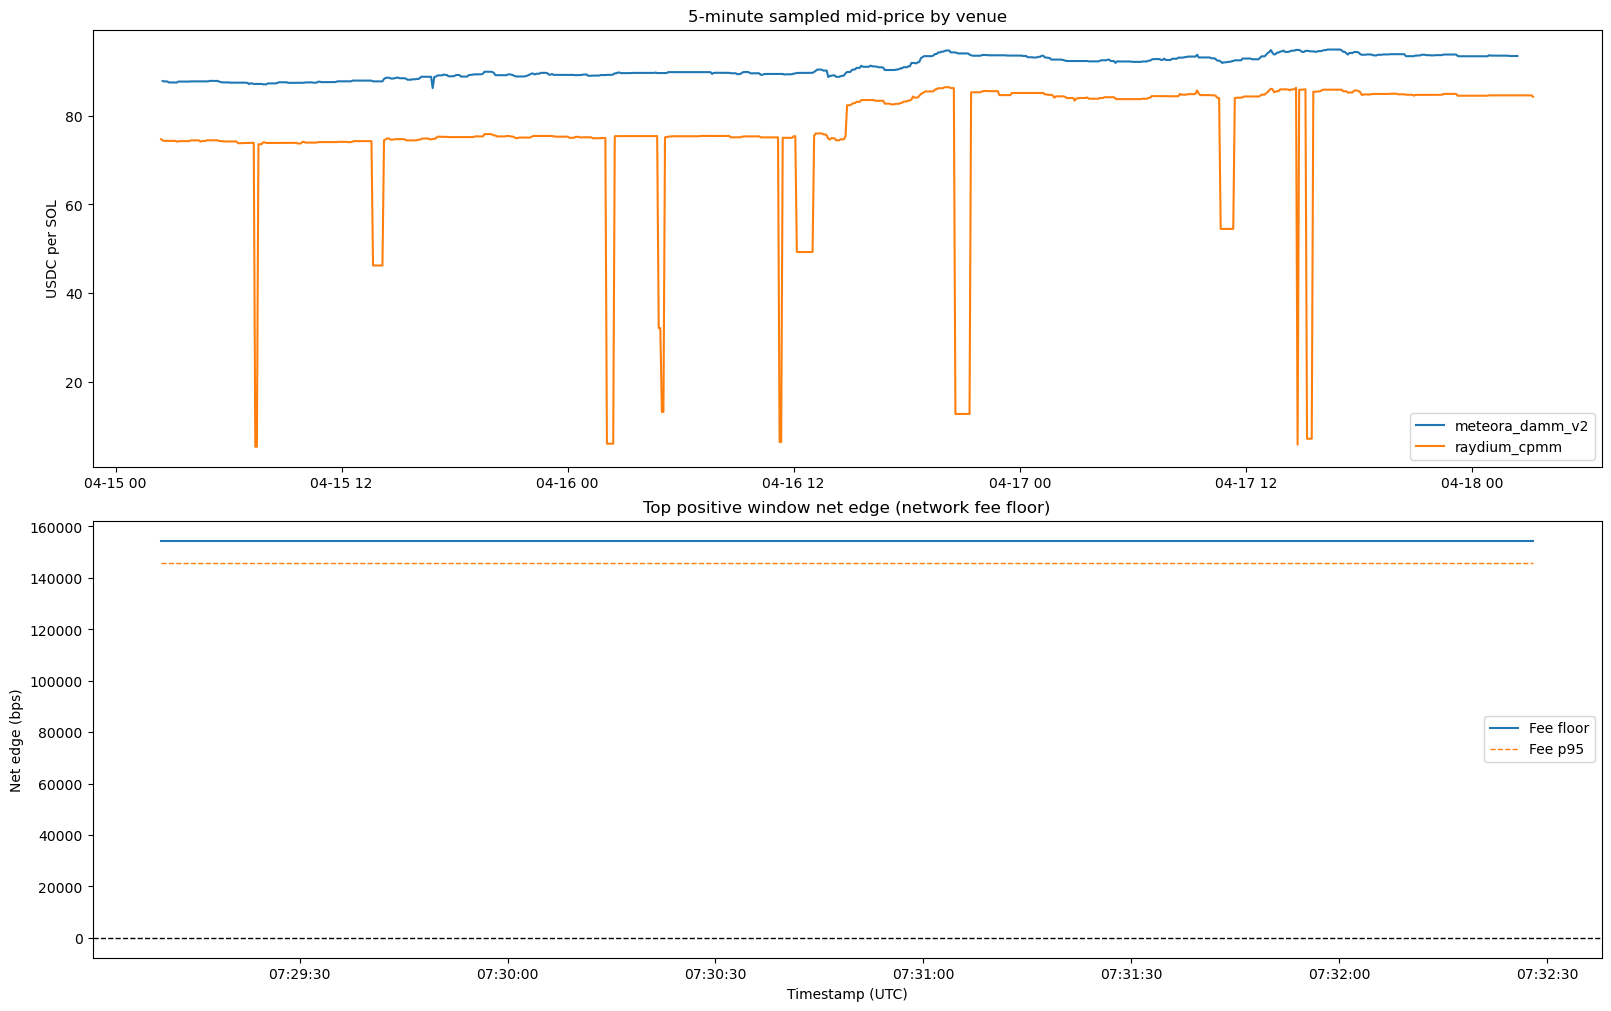

In [4]:
pool_state = dataset['pool_state'].copy()
arb_labels = dataset['arb_labels'].copy()
opportunity_windows = dataset['opportunity_windows'].copy()

display(Markdown('## Visual Checks'))
fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

price_plot = (
    pool_state.assign(plot_timestamp=pool_state['timestamp'].dt.floor('5min'))
    .groupby(['plot_timestamp', 'dex'], as_index=False)
    .agg(mid_price_quote_per_base=('mid_price_quote_per_base', 'last'))
)
for dex, group in price_plot.groupby('dex'):
    axes[0].plot(group['plot_timestamp'], group['mid_price_quote_per_base'], label=dex, linewidth=1.5)
axes[0].set_title('5-minute sampled mid-price by venue')
axes[0].set_ylabel('USDC per SOL')
axes[0].legend()

if not opportunity_windows.empty:
    best_window = opportunity_windows.iloc[0]
    mask = (arb_labels['timestamp'] >= best_window['start_timestamp']) & (arb_labels['timestamp'] <= best_window['end_timestamp'])
    plot_scores = arb_labels.loc[mask].sort_values('timestamp')
    axes[1].set_title('Top positive window net edge (network fee floor)')
else:
    plot_scores = arb_labels.nlargest(min(400, len(arb_labels)), 'net_edge_bps_floor').sort_values('timestamp')
    axes[1].set_title('Top scored seconds by lower-bound net edge')

axes[1].plot(plot_scores['timestamp'], plot_scores['net_edge_bps_floor'], linewidth=1.5, label='Fee floor')
if 'net_edge_bps_p95' in plot_scores.columns:
    axes[1].plot(plot_scores['timestamp'], plot_scores['net_edge_bps_p95'], linewidth=1.0, linestyle='--', label='Fee p95')
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_ylabel('Net edge (bps)')
axes[1].set_xlabel('Timestamp (UTC)')
axes[1].legend()
plt.show()


In [5]:
manifest_path = PROJECT_ROOT / 'outputs' / 'solana_research' / 'metadata' / 'dataset_manifest.json'
display(Markdown(f'## Manifest\n\nSaved manifest: `{manifest_path}`'))
if manifest_path.exists():
    manifest_payload = json.loads(manifest_path.read_text())
    display(pd.json_normalize(manifest_payload, sep='.', max_level=2).T.reset_index().rename(columns={'index': 'field', 0: 'value'}))


## Manifest

Saved manifest: `/Users/bilguuntsolmon/Desktop/main/uni/finance/fins3666/assignment3/outputs/solana_research/metadata/dataset_manifest.json`

,field,value
0,status,supported_with_limitations
1,market_slug,solana_research
2,chain_name,Solana
3,pair_label,SOL/USDC
4,sample_window_days,7
5,state_frequency,1s
6,window_start_utc,2026-04-12T06:31:51+00:00
7,window_end_utc,2026-04-19T06:31:51+00:00
8,selected_pools,"[{'dex': 'raydium_cpmm', 'source': 'raydium_v3..."
9,venue_catalog_rows,81
